<a href="https://colab.research.google.com/github/SaliniSree-17/Project/blob/main/Gold_Price_Prediction_Using_Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style = "color: green" >Simple Linear Regression Project (Gold Price Prediction) </span>
********


###  Introduction

Gold is a globally valued asset, widely used for investment and financial security. Its price changes over time due to economic conditions, inflation, and market demand. Predicting gold prices can help investors make informed decisions.

This project uses Simple Linear Regression to analyze historical data and model the relationship between time (independent variable) and gold price (dependent variable).

The Dataset contain gold prices (in USD) from 2001 to 2019. Our goal is to predict where the gold prices will be in the coming years.


### Problem Statement

Gold prices fluctuate continuously, making it difficult to predict future trends accurately. The challenge is to develop a model that can estimate gold prices based on historical data using a simple and interpretable approach.

###  Objective
 * To analyze historical trends in gold prices.
 * To build a predictive model using Simple Linear Regression.
 * To evaluate the model’s performance.
 * To forecast gold prices based on past data.

### Dataset Description

The dataset (gold_price_usd.csv) contains historical gold price data.

Typical columns include:

* Date / Time: Independent variable (X)
* Price (USD): Dependent variable (Y)

The dataset is structured and suitable for regression analysis after basic preprocessing.
***

## 1 .Import the necessary libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 2.  Load Dataset
***

#### Read 'gold_price_usd.csv' & store it in a variable


## 3. Dataset Description
***

In [13]:
from google.colab import files

uploaded = files.upload()

Saving gold_price_usd.csv to gold_price_usd (2).csv


In [14]:
df = pd.read_csv('gold_price_usd.csv')

#### View the first 5 rows

In [15]:
df.head()

,Date,USD (AM)
0,2001-01-02,272.80
1,2001-01-03,269.00
2,2001-01-04,268.75
3,2001-01-05,268.00
4,2001-01-08,268.60


#### View the last 5 rows

In [16]:
df.tail()

,Date,USD (AM)
4713,2019-08-27,1531.85
4714,2019-08-28,1541.75
4715,2019-08-29,1536.65
4716,2019-08-30,1526.55
4717,2019-09-02,1523.35


#### Check the information

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4718 entries, 0 to 4717
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      4718 non-null   object 
 1   USD (AM)  4718 non-null   float64
dtypes: float64(1), object(1)
memory usage: 73.8+ KB


#### Dataset Shape

In [18]:
df.shape

(4718, 2)

#### Column Names

In [19]:
df.columns

Index(['Date', 'USD (AM)'], dtype='object')

In [20]:
df.columns.tolist()

['Date', 'USD (AM)']

#### Statistical Summary


In [21]:
df.describe()

,USD (AM)
count,4718.000000
mean,959.990812
std,449.456217
min,256.700000
25%,449.112500
50%,1113.125000
75%,1293.750000
max,1896.500000


#### Missing Values Check

In [22]:
df.isnull().sum()

,0
Date,0
USD (AM),0


🔹 Column Description
* Date / Time → Represents time or sequence of data
* USD (AM) / Price → Represents gold price in USD

## 4. Data Preprocessing:
***


#### Rename USD (AM) to Price

In [23]:
df.rename(columns={'USD (AM)': 'Price'}, inplace=True)

In [24]:
df.head()

,Date,Price
0,2001-01-02,272.80
1,2001-01-03,269.00
2,2001-01-04,268.75
3,2001-01-05,268.00
4,2001-01-08,268.60


#### Convert Date column from object to datetime format¶

In [25]:
df["Date"] = pd.to_datetime(df["Date"])

In [26]:
df.isnull().sum()

,0
Date,0
Price,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4718 entries, 0 to 4717
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    4718 non-null   datetime64[ns]
 1   Price   4718 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 73.8 KB


In [28]:
df.dtypes

,0
Date,datetime64[ns]
Price,float64


In [29]:
# Drop missing values
df.dropna(inplace=True)

#### Duplicate values check

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
# if any duplicate uncomment this
# df.drop_duplicates(inplace=True)

## 5. Feature Engineering
***

#### Create a new column with Year & Months

In [32]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [33]:
df.head()

,Date,Price,Year,Month,Day
0,2001-01-02,272.80,2001,1,2
1,2001-01-03,269.00,2001,1,3
2,2001-01-04,268.75,2001,1,4
3,2001-01-05,268.00,2001,1,5
4,2001-01-08,268.60,2001,1,8


#### Check if there are any missing values in the dataset

In [34]:
df.isnull()

,Date,Price,Year,Month,Day
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
4713,False,False,False,False,False
4714,False,False,False,False,False
4715,False,False,False,False,False
4716,False,False,False,False,False


#### Check if any missing values exist

In [35]:
df.isnull().values.any()

np.False_

#### Total missing values in the whole DataFrame

In [36]:
df.isnull().sum()

,0
Date,0
Price,0
Year,0
Month,0
Day,0


#### Percentage of missing values (helpful for analysis)

In [37]:
(df.isnull().sum() / len(df)) * 100

,0
Date,0.0
Price,0.0
Year,0.0
Month,0.0
Day,0.0


#### Gather the basic statistical information about the dataset

In [38]:
df[["Price", "Year", "Month"]].describe()

,Price,Year,Month
count,4718.000000,4718.000000,4718.000000
mean,959.990812,2009.839339,6.456761
std,449.456217,5.392467,3.426217
min,256.700000,2001.000000,1.000000
25%,449.112500,2005.000000,3.000000
50%,1113.125000,2010.000000,6.000000
75%,1293.750000,2014.750000,9.000000
max,1896.500000,2019.000000,12.000000


### Dataset Shape

In [39]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 4718 rows and 5 columns


### See all the years and Month in our dataset¶

In [40]:
df.columns

Index(['Date', 'Price', 'Year', 'Month', 'Day'], dtype='object')

In [41]:
df["Year"].unique()

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019], dtype=int32)

In [42]:
df["Month"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [43]:
df["Day"].unique()

array([ 2,  3,  4,  5,  8,  9, 10, 11, 12, 15, 16, 17, 18, 19, 22, 23, 24,
       25, 26, 29, 30, 31,  1,  6,  7, 13, 14, 20, 21, 27, 28],
      dtype=int32)

## 6. Exploratory Data Analysis (EDA)
***

### Visualization

### Scatter Plot_ Bivariate Analysis (2 variables)

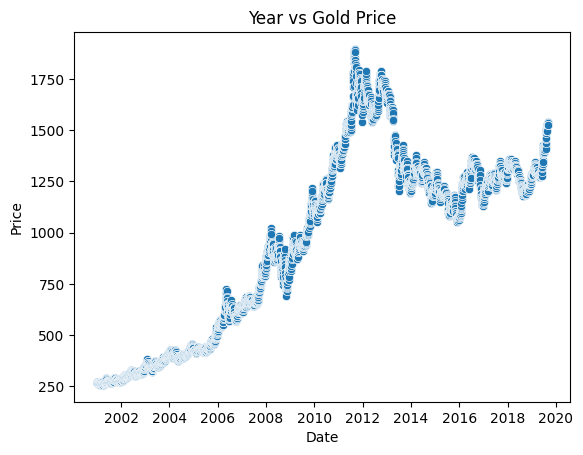

In [44]:
sns.scatterplot(x=df['Date'], y=df['Price'])
plt.title("Year vs Gold Price")
plt.show()

#### Univariate Analysis (single column analysis)

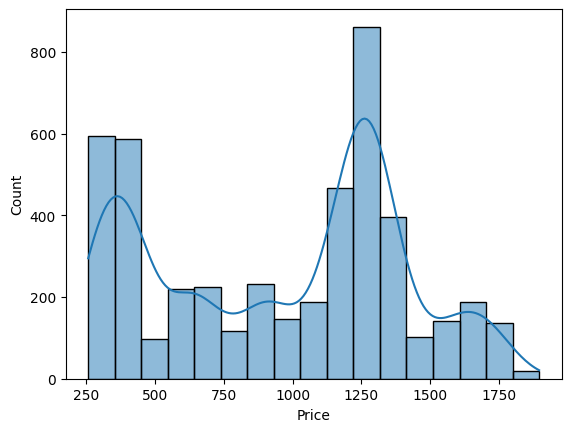

In [45]:
sns.histplot(df['Price'], kde=True)
plt.show()

### Trend Analysis

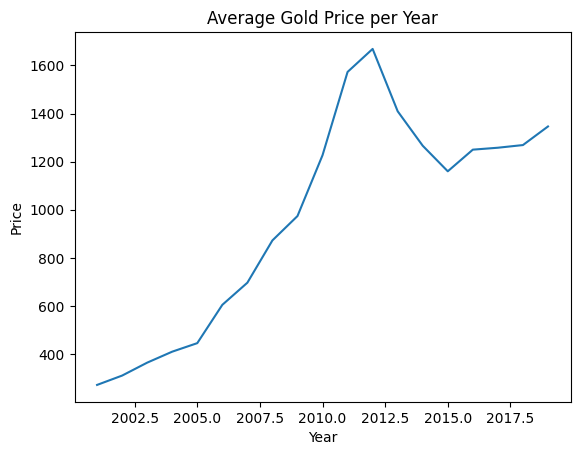

In [46]:
yearly_avg = df.groupby('Year')['Price'].mean()

yearly_avg.plot()
plt.title("Average Gold Price per Year")
plt.ylabel("Price")
plt.show()

### Correlation analysis

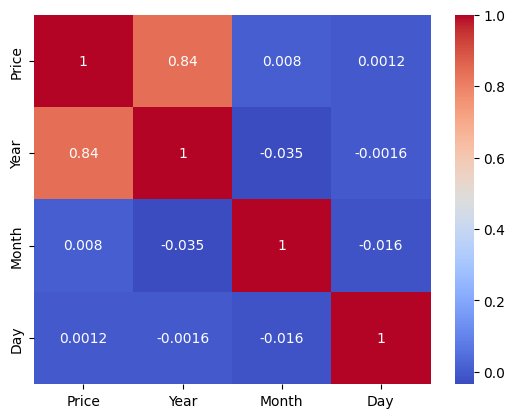

In [47]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Create a regression plot with x-axis as years and y-axis as Price


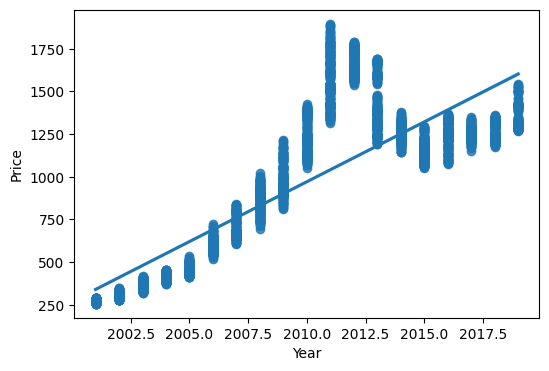

In [48]:
plt.figure(figsize = (6,4))
sns.regplot(x = "Year", y = "Price", data = df)
plt.show()

### Plot a histplot to find the variation in price

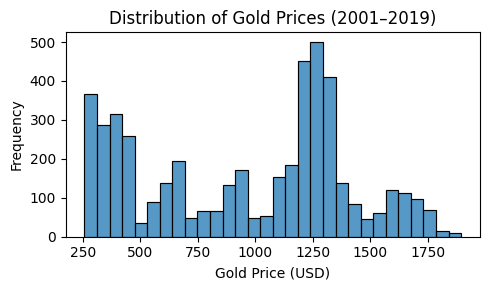

In [49]:
plt.figure(figsize=(5, 3))
sns.histplot(df["Price"], bins=30)
plt.xlabel("Gold Price (USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Gold Prices (2001–2019)")
plt.tight_layout()
plt.show()

## 7. Model Building
***

#### Assign Year and Price in X and y variables


In [50]:
X = df[['Year']]
y = df['Price']

#### Split the data into traning and testin set

We will train our model on the training set and then use the test set to evaluate the model

In [51]:
# import train_test split
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state=100)

#### Train Data

In [53]:
# import LinearRegression from sklearn
from sklearn.linear_model import LinearRegression

#### Create Linear Regression Model

In [54]:
model = LinearRegression()

### Train the model

In [55]:
model.fit(X_train, y_train)

LinearRegression()

### LinearRegression()
In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

#### Check the score of our model

In [56]:
score = model.score(X_test, y_test)
print(f"Model R² Score: {score:.4f}")

Model R² Score: 0.7125


#### Check the coefficient and Intercept

In [57]:
# print the intercept
print(f"Intercept (b): {model.intercept_:.2f}")

Intercept (b): -140074.32


In [58]:
# print the coefficient
print(f"Coefficient / Slope (m): {model.coef_[0]:.4f}")

Coefficient / Slope (m): 70.1737


### 8. Prediction
***

#### Make Prediction with Test data

In [59]:
y_pred = model.predict(X_test)

print("Predictions (first 10):")
print(y_pred[:10].round(2))

Predictions (first 10):
[ 553.71  413.36 1185.27  764.23  904.58  413.36  343.19  694.06 1185.27
 1325.62]


Report

The trained model was used to predict gold prices on the test dataset. The first 10 predicted values were displayed and rounded to two decimal places for better readability.

### 9. Evaluation Metrics
***

#### Check the mean absolute error, mean square error

In [60]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [61]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.712548188045684


In [62]:
# Mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 186.24


In [63]:
# Mean squared error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error  (MSE):  {mse:.2f}")
print(f"Root Mean Sq Error  (RMSE): {rmse:.2f}")

Mean Squared Error  (MSE):  58032.97
Root Mean Sq Error  (RMSE): 240.90


In [64]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 240.90033991036876


### Calculated Metrics
 * R² Score: 0.71
* Mean Absolute Error (MAE): 186.24
* Mean Squared Error (MSE): 58032.97
* Root Mean Squared Error (RMSE): 240.9

### Interpretation

The R² score of 0.71 indicates that the model explains about 71% of the variance in gold prices, which shows a reasonably good fit.

The Mean Absolute Error (MAE) of 186.24 indicates that, on average, the predicted gold prices differ from actual values by approximately 186 units.

The Root Mean Squared Error (RMSE) of 240.90 is higher than MAE, indicating the presence of some larger errors in prediction, as RMSE penalizes larger deviations more strongly.

Overall, the model shows moderate accuracy, but prediction errors exist due to the simplicity of the model and the use of limited features.

## 10. Actual vs Predicted Table

In [65]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results.head()

,Actual,Predicted
0,425.50,553.709468
1,307.80,413.362129
2,1335.75,1185.272491
3,687.25,764.230476
4,924.75,904.577814


### Predict the prices for the following years
* 2025, 2026, 2027, 2028, 2030

In [66]:
future_years = [[2025], [2026], [2027], [2028], [2030]]
future_predictions = model.predict(future_years)

future_df = pd.DataFrame({
    "Year": [2025, 2026, 2027, 2028, 2030],
    "Predicted Gold Price (USD)": future_predictions.round(2)
})
print(future_df.to_string(index=False))

 Year  Predicted Gold Price (USD)
 2025                     2027.36
 2026                     2097.53
 2027                     2167.70
 2028                     2237.88
 2030                     2378.22


#### Plot a graph to check the accuracy of our prediction

In [67]:
len(y_pred)

1416

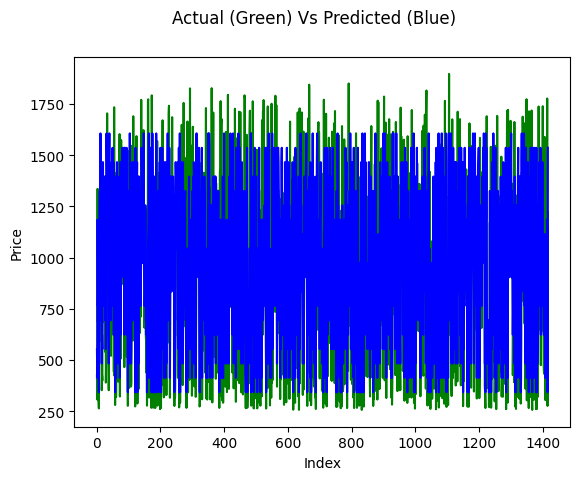

In [68]:
c = [i for i in range(1,1417,1)]   #Creating an Index, 1417 is used because we have a total of 1416 data in our testing set
fig = plt.figure()
plt.plot(c,y_test, color = 'green') # Plotting y test
plt.plot(c,y_pred, color = 'blue') # Plotting predicted values
fig.suptitle('Actual (Green) Vs Predicted (Blue)') # Set title
plt.xlabel('Index') # Set X label
plt.ylabel('Price') # Set Y label
plt.show()

## 11.  Accuracy Visualization
****

#### Plot a scatter plot of Actual vs Predicted Scatter

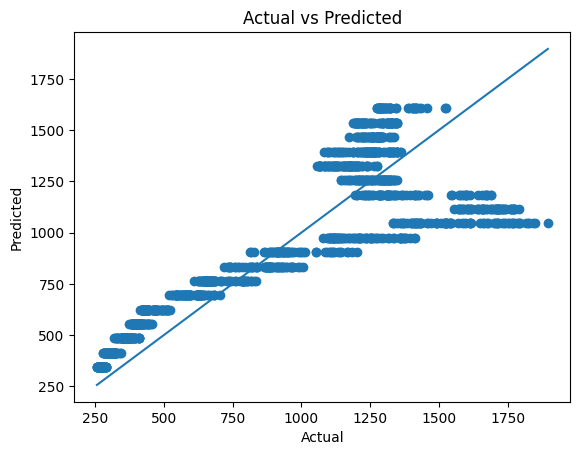

In [69]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.title("Actual vs Predicted")
plt.show()

## 12.  Residual Plot

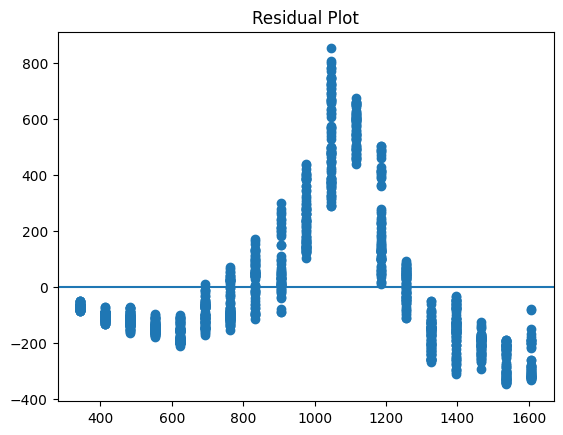

In [70]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.show()

## 13. Prediction -2026

In [71]:
model.predict([[2026]])

array([2097.53019181])

### 14. Model Analysis

The Linear Regression model performs well in capturing the overall trend in gold prices over time. However, it fails to accurately predict real-world prices due to its inability to handle sudden fluctuations and the influence of external factors such as inflation, market demand, and global economic conditions. Therefore, the model is suitable for basic trend analysis but not for precise forecasting.

### 15.Detailed Analysis

The Simple Linear Regression model captures the overall upward trend in gold prices but fails to reflect sudden fluctuations. This indicates limited capability in handling real-world financial variation.

### 16. Limitations

The model uses only a single variable and cannot account for important factors like inflation, global economy, and market demand. Hence, its prediction accuracy is limited.

### 17. Discussion

The results show that while the model is useful for understanding general trends, it is not suitable for precise financial forecasting. More complex models are required for better performance.

### 18. Suggestions

Advanced models like ARIMA and LSTM can be used to improve prediction accuracy by capturing time-based patterns.

### 19. Prediction Example

For a given input value, the model predicts a corresponding gold price based on past trends. However, the prediction may not be accurate due to real-world market fluctuations.

### 20. Real-World Explanation

This project uses Simple Linear Regression to understand the general trend of gold prices. However, since real-world prices depend on many factors, the model provides only a basic idea and is not fully reliable for accurate prediction.

## 21. Final Conclusion

In this project, Simple Linear Regression was used to predict gold prices. Although the model is able to capture a general trend, it is not sufficient for accurately modeling such complex financial data.

Gold prices are influenced by multiple factors, including inflation, global economic conditions, geopolitical events, and currency fluctuations. As a result, a single-variable regression model cannot provide reliable real-world predictions.

To improve accuracy, more advanced techniques such as Multiple Linear Regression or Time Series models (e.g., ARIMA, LSTM) should be considered in future work.

### Project Completed
***